# 05 · Diario de experimentos y resultados

Este cuaderno reúne las pruebas de nuestra CNN para **predecir pCR** desde PRE/EARLY/LATE. No detecta tumores, no usa RGB y no es un producto clínico.

**Uso educativo, sin validez clínica. Test permanece cerrado.** Todas las cifras científicas aquí corresponden a validación interna por paciente: fold 0, seed 42, media de probabilidades por paciente y umbral 0,5.

Puedes ejecutar **todas las celdas**: solo leen métricas agregadas y dibujan figuras. No entrenan, no hacen inferencia, no leen PNG, no cargan pesos ni consultan test. Los smoke tests quedan fuera de la comparación.

El respaldo permanente está en [resultados_registrados.json](../experimentos/resultados_registrados.json). Si faltan informes de la universidad, se mantienen las cifras comunicadas pero no se inventan curvas. Los informes locales válidos actualizan la vista al ejecutar el cuaderno de nuevo. Una salida guardada es una fotografía del estado en la última ejecución, no una actualización automática.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

HERE = Path.cwd().resolve()
ROOT = next((p for p in (HERE, *HERE.parents)
             if (p / "src/results_notebook.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Abre este cuaderno dentro del repositorio del proyecto")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.results_notebook import load_results, load_histories, load_cohort_reports

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
results, missing_details = load_results(ROOT)
histories = load_histories(ROOT, results)
registry = json.loads((ROOT / "experimentos/resultados_registrados.json").read_text())
print("Lectura de informes agregados; no entrenamiento ni test.")

Lectura de informes agregados; no entrenamiento ni test.


## 1. Cómo leer los resultados

- **ROC-AUC**: cuánto distingue y ordena las dos clases. 0,5 es la referencia aleatoria; cambiar el umbral no aumenta este AUC.
- **PR-AUC / AP**: resume precisión y sensibilidad; depende de la prevalencia. Nuestra implementación usa average precision, no área trapezoidal.
- **Sensitivity**: proporción de pacientes pCR=1 que clasifica como positivas al umbral establecido. Una accuracy de aproximadamente 70,8 % puede obtenerse prediciendo siempre pCR=0.
- **Mejor época**: elegida por AUC por paciente de validación. No seleccionar después otra época porque tenga mejor AP.
- **Pérdida train frente a validación**: bajar train mientras empeora validación sugiere sobreajuste; no identifica la causa ni demuestra qué rasgo ha memorizado.

Datos internos habituales: 878 pacientes de entrenamiento y 219 de validación (155 negativas y 64 positivas), no 10.945 observaciones independientes. Los cortes de una misma paciente están correlacionados.

## 2. Registro completo de ejecuciones

El mismo experimento puede tener ejecuciones diferentes: E05 universitario y E05 Mac tienen identidades y carpetas separadas. Un resultado pendiente no se transforma en cero. Las épocas históricas no comunicadas quedan vacías.

In [2]:
columns = ["run_id", "change", "status", "device", "parameter_count", "best_epoch",
           "roc_auc", "pr_auc", "source"]
display(results[columns].round({"roc_auc": 4, "pr_auc": 4}))

,run_id,change,status,device,parameter_count,best_epoch,roc_auc,pr_auc,source
0,E02_universidad,Dos convoluciones antes del pooling,complete,cuda/ROCm,294129,1.0,0.6204,0.3766,student_terminal_summary
1,E03_universidad,BCE ponderada sobre E02,complete,cuda/ROCm,294129,NaN,0.6029,0.3736,student_terminal_summary
2,E04_universidad,Una convolución por bloque,complete,cuda/ROCm,97809,NaN,0.5998,0.3362,student_terminal_summary
3,E05_universidad,Pooling entre dos convoluciones,complete,cuda/ROCm,294129,1.0,0.6140,0.3910,student_terminal_summary
4,E06_universidad,Quinto bloque con pooling,complete,cuda/ROCm,589553,6.0,0.5746,0.3672,student_terminal_summary
5,E07_universidad,"Dropout 0,5 sobre E05",complete,cuda/ROCm,294129,1.0,0.5956,0.3689,student_terminal_summary
6,E08_mac,"Weight decay 0,001 sobre E05",complete,mps,294129,3.0,0.5827,0.3554,local_artifacts
7,E09_universidad,Rotación/traslación sincronizada en train,complete,cuda/ROCm,294129,1.0,0.6103,0.3758,student_terminal_summary
8,E10_mac,"Mitad de canales, misma profundidad",complete,mps,73913,6.0,0.5906,0.3791,local_artifacts
9,E05_mac,"Referencia E05 en el Mac, rutas nuevas",complete,mps,294129,1.0,0.5869,0.3742,local_artifacts


### Procedencia y reproducibilidad

`local_artifacts` significa que hay un summary/config local validado. `student_terminal_summary` significa que se transcribió la cifra agregada comunicada por el estudiante; la precisión y la información disponibles son limitadas. **No fabricamos historia por época a partir de un único resumen.**

In [3]:
display(results[["run_id", "config", "report_dir", "local_history_available", "source_note"]])
if missing_details:
    display(pd.DataFrame(missing_details))

,run_id,config,report_dir,local_history_available,source_note
0,E02_universidad,E02_base_normal.json,reports/experiments/E02_base_normal/fold_0_see...,False,Salida de terminal compartida por el estudiant...
1,E03_universidad,E03_base_weighted.json,reports/experiments/E03_base_weighted/fold_0_s...,False,Salida de terminal compartida por el estudiant...
2,E04_universidad,E04_one_conv_normal.json,reports/experiments/E04_one_conv_normal/fold_0...,False,Salida de terminal compartida por el estudiant...
3,E05_universidad,E05_pool_between_convs.json,reports/experiments/E05_pool_between_convs/fol...,False,Salida de terminal compartida por el estudiant...
4,E06_universidad,E06_five_blocks_normal.json,reports/experiments/E06_five_blocks_normal/fol...,False,Salida de terminal compartida por el estudiant...
5,E07_universidad,E07_dropout_050.json,reports/experiments/E07_dropout_050/fold_0_see...,False,Salida de terminal compartida por el estudiant...
6,E08_mac,E08_weight_decay_001.json,reports/experiments/E08_weight_decay_001/fold_...,True,Informe agregado local validado; no se leen id...
7,E09_universidad,E09_shared_affine.json,reports/experiments/E09_shared_affine/fold_0_s...,False,Salida de terminal compartida por el estudiant...
8,E10_mac,E10_half_width.json,reports/experiments/E10_half_width/fold_0_seed_42,True,Informe agregado local validado; no se leen id...
9,E05_mac,E05_mac_reference.json,reports/experiments/E05_mac_reference/fold_0_s...,True,Informe agregado local validado; no se leen id...


,run_id,note
0,E02_universidad,Solo resumen comunicado; no reconstruir curvas...
1,E03_universidad,Solo resumen comunicado; no reconstruir curvas...
2,E04_universidad,Solo resumen comunicado; no reconstruir curvas...
3,E05_universidad,Solo resumen comunicado; no reconstruir curvas...
4,E06_universidad,Solo resumen comunicado; no reconstruir curvas...
5,E07_universidad,Solo resumen comunicado; no reconstruir curvas...
6,E09_universidad,Solo resumen comunicado; no reconstruir curvas...


## 3. Vista de AUC y AP: no es un ranking definitivo

Los colores distinguen plataformas, no calidad. La línea de 0,7 representa el objetivo comentado por el profesor, **no una garantía**. Los experimentos han usado presupuestos diferentes en algunos baselines y hemos consultado repetidamente este fold. No declarar ganador a partir de esta figura: faltan confirmación por semillas/folds e incertidumbre pareada.

CUDA/ROCm podía usar precisión mixta; el Mac MPS usa float32 en nuestro runner. La misma semilla no garantiza entrenamientos iguales entre dispositivos.

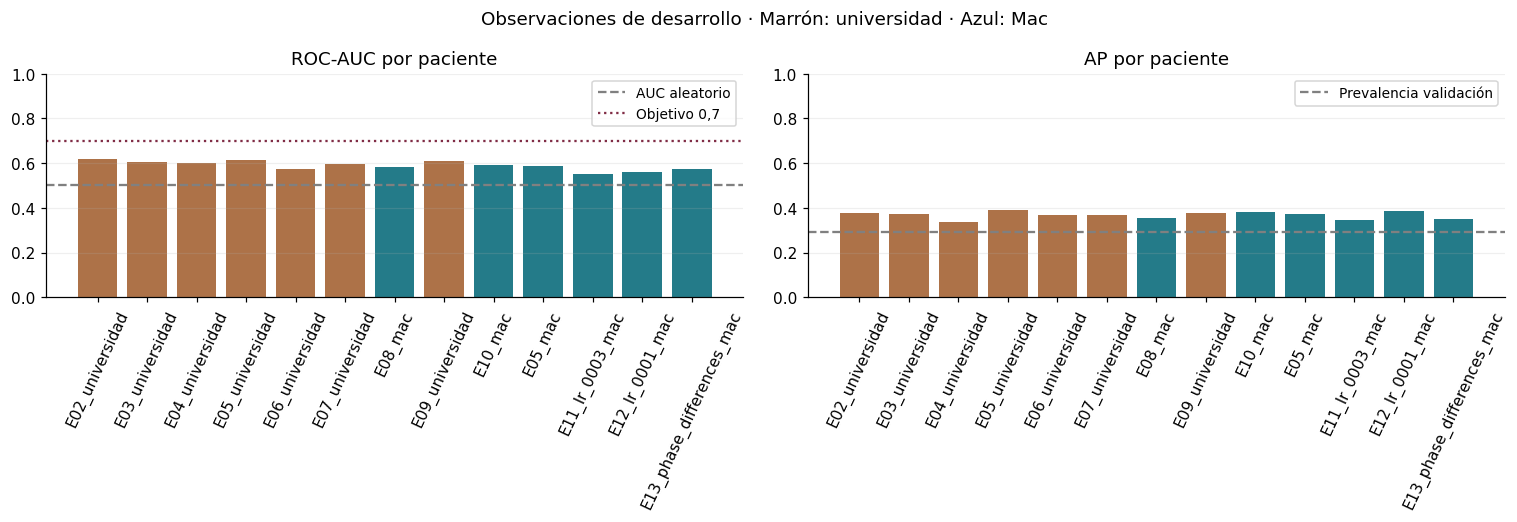

In [4]:
completed = results[results.status == "complete"].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors = ["#247b89" if device == "mps" else "#ad7248" for device in completed.device]
for axis, metric, title in zip(axes, ["roc_auc", "pr_auc"], ["ROC-AUC por paciente", "AP por paciente"]):
    axis.bar(completed.run_id, completed[metric], color=colors)
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=65)
    axis.grid(axis="y", alpha=.2)
axes[0].axhline(.5, color="grey", linestyle="--", label="AUC aleatorio")
axes[0].axhline(.7, color="#802c45", linestyle=":", label="Objetivo 0,7")
axes[1].axhline(64/219, color="grey", linestyle="--", label="Prevalencia validación")
for axis in axes:
    axis.legend(fontsize=9)
fig.suptitle("Observaciones de desarrollo · Marrón: universidad · Azul: Mac")
fig.tight_layout()
plt.show()

## 4. Evolución por época: solo historiales disponibles

Dos paneles por ejecución: pérdidas y métricas de validación. La marca vertical indica el checkpoint elegido por AUC. Si no hay history.csv local, no mostramos una curva inventada. AUC de validación **no es AUC de entrenamiento**.

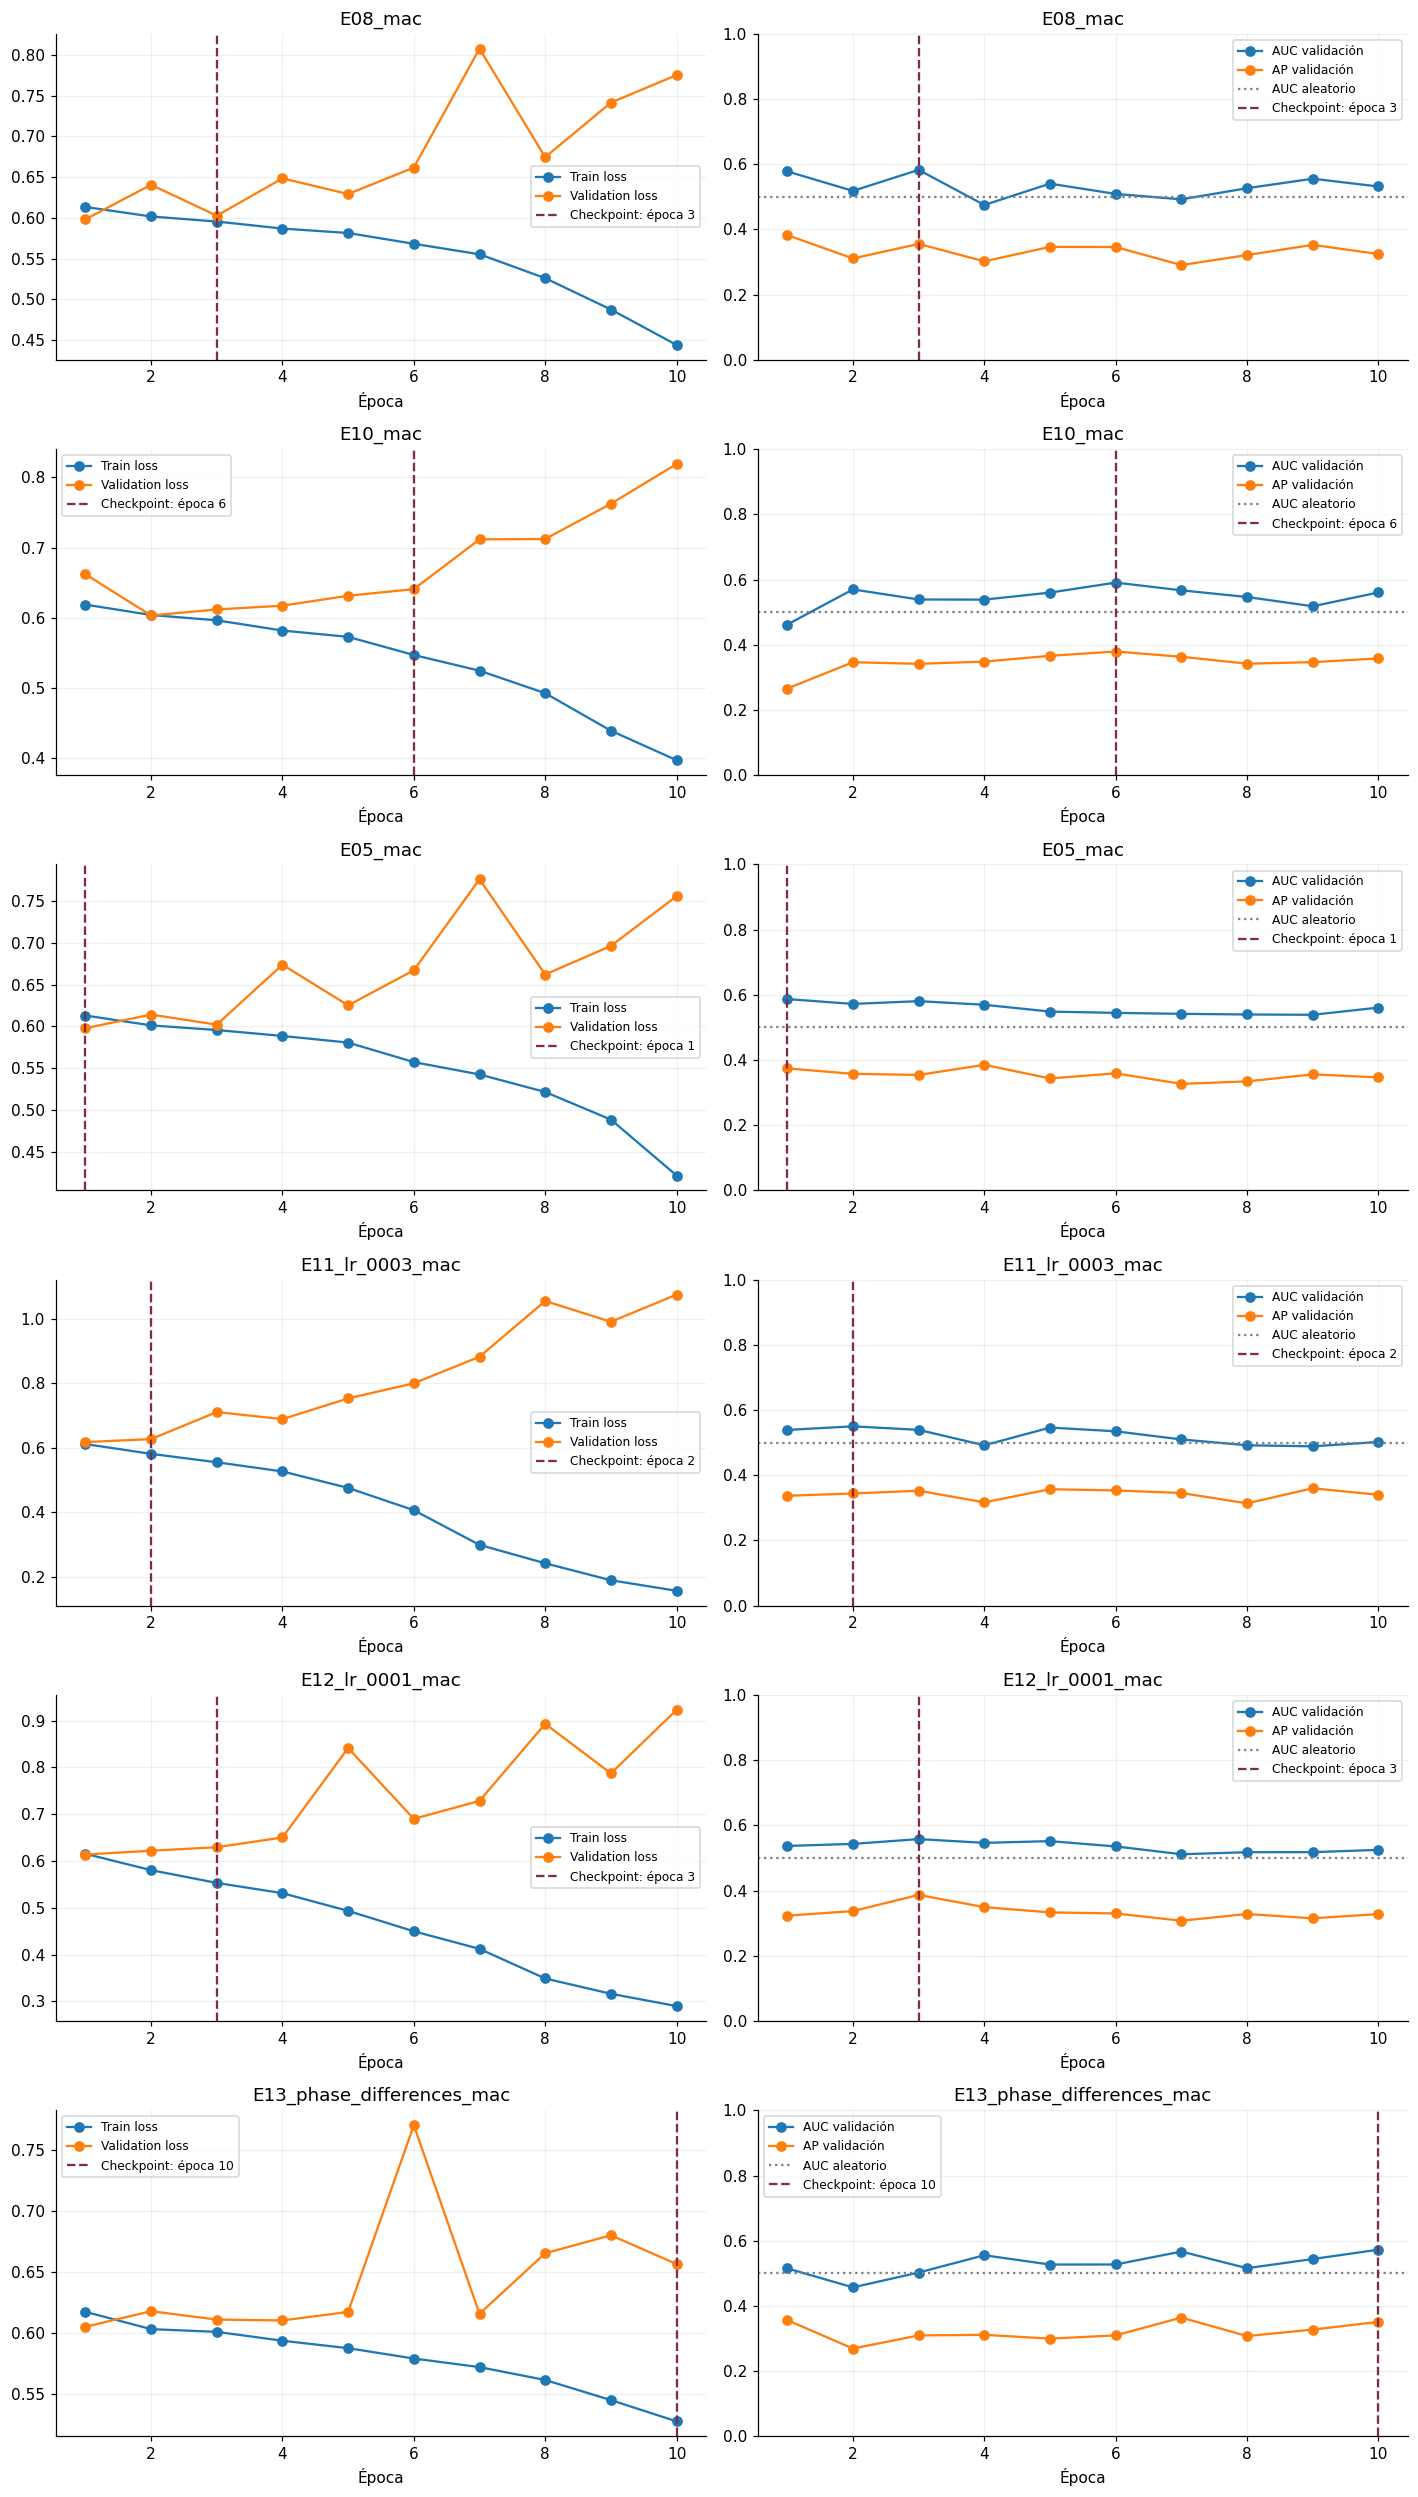

In [5]:
if not histories:
    display(Markdown("No hay historiales locales. La tabla histórica sigue disponible."))
else:
    fig, axes = plt.subplots(len(histories), 2, figsize=(13, 3.8 * len(histories)), squeeze=False)
    for index, (run_id, history) in enumerate(histories.items()):
        best_epoch = int(results.loc[results.run_id == run_id, "best_epoch"].iloc[0])
        axes[index, 0].plot(history.epoch, history.train_loss, "o-", label="Train loss")
        axes[index, 0].plot(history.epoch, history.validation_loss, "o-", label="Validation loss")
        axes[index, 1].plot(history.epoch, history.patient_roc_auc, "o-", label="AUC validación")
        axes[index, 1].plot(history.epoch, history.patient_pr_auc, "o-", label="AP validación")
        axes[index, 1].axhline(.5, color="grey", linestyle=":", label="AUC aleatorio")
        axes[index, 1].set_ylim(0, 1)
        for axis in axes[index]:
            axis.axvline(best_epoch, color="#802c45", linestyle="--", label=f"Checkpoint: época {best_epoch}")
            axis.set_xlabel("Época")
            axis.set_title(run_id)
            axis.grid(alpha=.2)
            axis.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

## 5. Diagnóstico E05: aprendizaje inicial, sobreajuste posterior y BatchNorm

Estos dos checkpoints universitarios se evaluaron con el mismo modo de inferencia, sin aumentos y con dropout apagado. La copia BN recalcula estadísticas **solo con train**, sin actualizar pesos aprendidos, sin modificar el archivo original y sin desplegar la copia. No confundir esa operación con calibración de probabilidades.

El checkpoint de época 1 tenía AUC train/val 0,587/0,614. En época 10, 0,870/0,580: aparece una brecha clara de generalización. Los intervalos del cambio de AUC tras recalcular BN incluyen cero; no hay evidencia suficiente de que BN sea la solución.

Diagnóstico E05 universitario compartido por el estudiante; copia BN ajustada solo con train, sin modificar checkpoint. Intervalos exploratorios de 500 remuestreos pareados.

,epoch,train_auc,validation_auc,train_auc_bn,validation_auc_bn,delta_ci_lower,delta_ci_upper
0,1,0.5870,0.6140,0.5864,0.6173,-0.0032,0.0101
1,10,0.8695,0.5797,0.8740,0.5901,-0.0039,0.0245


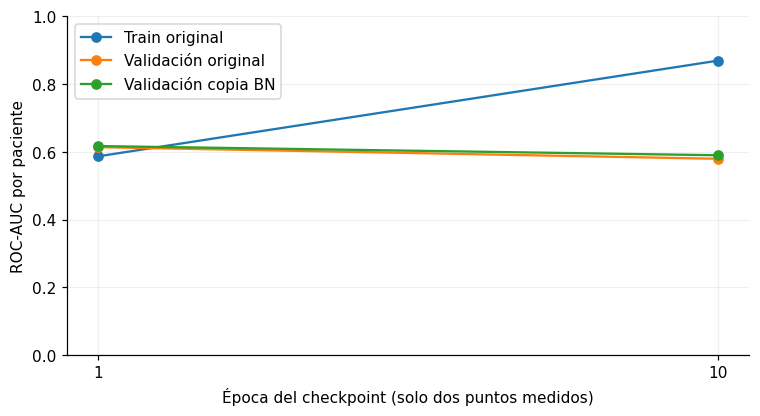

In [6]:
bn = pd.DataFrame(registry["batchnorm_diagnosis"])
display(Markdown(registry["batchnorm_source"]))
display(bn.round(4))
fig, axis = plt.subplots(figsize=(8, 4))
for column, label in [("train_auc", "Train original"), ("validation_auc", "Validación original"),
                      ("validation_auc_bn", "Validación copia BN")]:
    axis.plot(bn.epoch, bn[column], "o-", label=label)
axis.set(xlabel="Época del checkpoint (solo dos puntos medidos)", ylabel="ROC-AUC por paciente", ylim=(0, 1))
axis.set_xticks([1, 10])
axis.grid(alpha=.2)
axis.legend()
plt.show()

## 6. Análisis por cohorte y comparación pareada

Duke, I-SPY1 e I-SPY2 son procedencias del dataset, no nuevas entradas de la CNN. Se anotan por paciente en un informe separado. AUC global y AUC dentro de cohortes comparan conjuntos de pares distintos: sus diferencias son pistas, **no pruebas causales de sesgo**.

Mostrar solo estadísticas agregadas: este cuaderno no carga los CSV con identificadores. AP depende de prevalencia. Los intervalos bootstrap son exploratorios, condicionados a la composición observada y no corrigen selección de checkpoint ni múltiples ensayos. I-SPY1 aporta solo cuatro positivas en este fold; no sacar conclusiones fuertes de ese grupo.

**Procedencia:** Informe local

,experiment,cohort,patients,positive,AUC,CI_lower,CI_upper,AP,sensitivity,specificity,small_group
0,E08_weight_decay_001,ALL,219,64,0.5827,0.5031,0.6613,0.3554,0.0000,1.0000,False
1,E08_weight_decay_001,duke,42,11,0.4633,0.2741,0.6643,0.2545,0.0000,1.0000,False
2,E08_weight_decay_001,spy1,21,4,0.5735,0.2059,0.9489,0.4786,0.0000,1.0000,True
3,E08_weight_decay_001,spy2,156,49,0.5970,0.4975,0.6982,0.3996,0.0000,1.0000,False
4,E10_half_width,ALL,219,64,0.5906,0.5138,0.6758,0.3791,0.0625,0.9677,False
5,E10_half_width,duke,42,11,0.5601,0.3752,0.7526,0.3087,0.0000,0.9677,False
6,E10_half_width,spy1,21,4,0.6176,0.2941,0.8901,0.3255,0.0000,1.0000,True
7,E10_half_width,spy2,156,49,0.5785,0.4694,0.6774,0.4110,0.0816,0.9626,False


,reference,candidate,cohort,difference,lower,upper
0,E08_weight_decay_001,E10_half_width,ALL,0.0080,-0.0782,0.0793
1,E08_weight_decay_001,E10_half_width,duke,0.0968,-0.1026,0.3081
2,E08_weight_decay_001,E10_half_width,spy1,0.0441,-0.4489,0.4706
3,E08_weight_decay_001,E10_half_width,spy2,-0.0185,-0.1140,0.0729


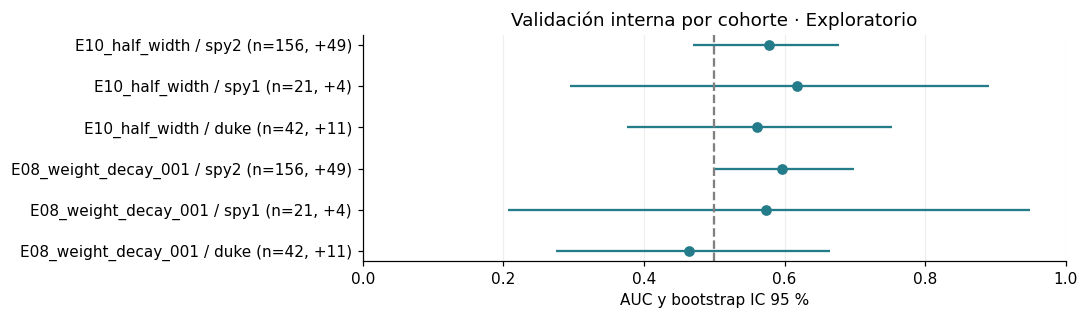

**Procedencia:** Informe local

,experiment,cohort,patients,positive,AUC,CI_lower,CI_upper,AP,sensitivity,specificity,small_group
0,E05_mac_reference,ALL,219,64,0.5869,0.5125,0.6611,0.3742,0.0000,1.0000,False
1,E05_mac_reference,duke,42,11,0.3812,0.2023,0.5763,0.2347,0.0000,1.0000,False
2,E05_mac_reference,spy1,21,4,0.6176,0.2353,0.9706,0.5292,0.0000,1.0000,True
3,E05_mac_reference,spy2,156,49,0.6151,0.5212,0.7174,0.4518,0.0000,1.0000,False
4,E08_weight_decay_001,ALL,219,64,0.5827,0.5031,0.6613,0.3554,0.0000,1.0000,False
5,E08_weight_decay_001,duke,42,11,0.4633,0.2741,0.6643,0.2545,0.0000,1.0000,False
6,E08_weight_decay_001,spy1,21,4,0.5735,0.2059,0.9489,0.4786,0.0000,1.0000,True
7,E08_weight_decay_001,spy2,156,49,0.5970,0.4975,0.6982,0.3996,0.0000,1.0000,False
8,E10_half_width,ALL,219,64,0.5906,0.5138,0.6758,0.3791,0.0625,0.9677,False
9,E10_half_width,duke,42,11,0.5601,0.3752,0.7526,0.3087,0.0000,0.9677,False


,reference,candidate,cohort,difference,lower,upper
0,E05_mac_reference,E08_weight_decay_001,ALL,-0.0042,-0.0409,0.0328
1,E05_mac_reference,E08_weight_decay_001,duke,0.0821,-0.0176,0.2025
2,E05_mac_reference,E08_weight_decay_001,spy1,-0.0441,-0.1765,0.0441
3,E05_mac_reference,E08_weight_decay_001,spy2,-0.0181,-0.0619,0.0263
4,E05_mac_reference,E10_half_width,ALL,0.0037,-0.0769,0.0772
5,E05_mac_reference,E10_half_width,duke,0.1789,0.0043,0.3769
6,E05_mac_reference,E10_half_width,spy1,0.0000,-0.4706,0.4265
7,E05_mac_reference,E10_half_width,spy2,-0.0366,-0.1334,0.0592


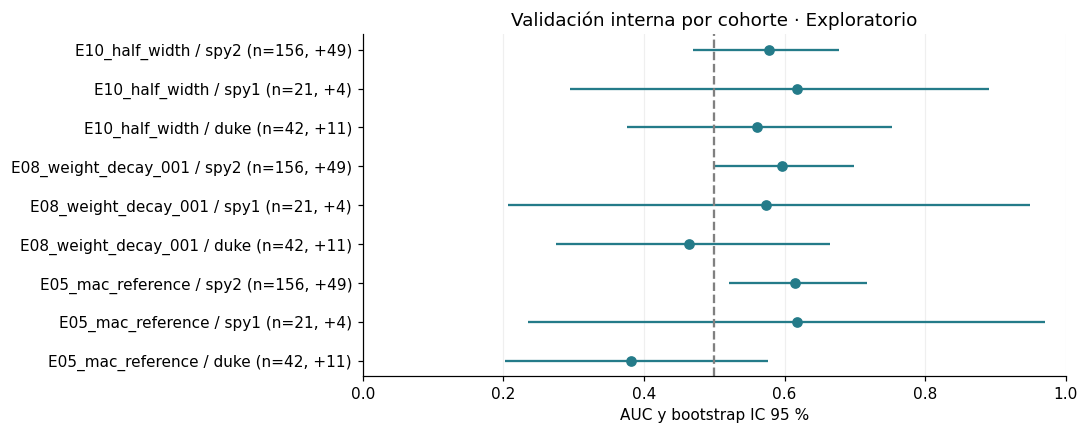

In [7]:
cohort_reports = load_cohort_reports(ROOT)
if not cohort_reports:
    display(Markdown("No hay informes locales por cohorte. Véase el protocolo en experimentos/COHORTES_Y_REFERENCIA_MAC.md."))
for report in cohort_reports:
    display(Markdown('**Procedencia:** ' + report.get('notebook_source', 'Informe agregado')))
    rows, paired_rows = [], []
    for experiment in report["experiments"]:
        for cohort, stats in experiment["groups"].items():
            ci = stats["intervals"]["roc_auc"]
            rows.append({"experiment": experiment["experiment_id"], "cohort": cohort,
                         "patients": stats["n"], "positive": stats["positive"],
                         "AUC": stats["metrics"]["roc_auc"], "CI_lower": ci["lower"], "CI_upper": ci["upper"],
                         "AP": stats["metrics"]["pr_auc"], "sensitivity": stats["metrics"]["sensitivity"],
                         "specificity": stats["metrics"]["specificity"], "small_group": stats["small_group_warning"]})
    for comparison in report["paired_comparisons"]:
        for cohort, values in comparison["auc_delta"].items():
            paired_rows.append({"reference": comparison["reference"], "candidate": comparison["candidate"],
                                "cohort": cohort, **values})
    table = pd.DataFrame(rows)
    display(table.round(4))
    if paired_rows:
        display(pd.DataFrame(paired_rows).round(4))
    groups = table[table.cohort != "ALL"]
    fig, axis = plt.subplots(figsize=(10, max(3, len(groups) * .45)))
    for position, row in enumerate(groups.itertuples()):
        if pd.notna(row.AUC):
            axis.hlines(position, row.CI_lower, row.CI_upper, color="#247b89")
            axis.plot(row.AUC, position, "o", color="#247b89")
    axis.set_yticks(range(len(groups)), labels=[f"{r.experiment} / {r.cohort} (n={r.patients}, +{r.positive})" for r in groups.itertuples()])
    axis.axvline(.5, color="grey", linestyle="--")
    axis.set(xlim=(0, 1), xlabel="AUC y bootstrap IC 95 %", title="Validación interna por cohorte · Exploratorio")
    axis.grid(axis="x", alpha=.2)
    fig.tight_layout()
    plt.show()

## 7. Qué hemos aprendido y qué sigue pendiente

Diagnóstico E13 completado en MPS: ROC-AUC train 0,788197 frente a validación 0,572480. La copia BatchNorm ajustada solo con train da validación 0,557964: delta −0,014516, IC exploratorio 95 % [−0,029791; −0,000955]. No resuelve la generalización; no prolongar automáticamente. Sin cambios al checkpoint ni test. [Ficha y snapshot agregado](../experimentos/DIAGNOSTICO_E13.md). El intento previo CPU se interrumpió y no se considera informe final.

E13 completó diez épocas en Mac MPS: mejor época 10, ROC-AUC paciente 0,572480 y AP 0,350860, en 421,48 s. No supera E05 Mac (0,586895). A umbral 0,5 obtiene 14 verdaderos positivos y 23 falsos positivos. La loss train termina en 0,5275 y validación en 0,6566. Que la mejor época sea la última no demuestra que prolongar funcione; se diagnostica train/validación antes de decidir. Protocolo: [realce E13](../experimentos/REALCE_E13.md).

- E02 alcanzó aproximadamente 0,6204, E05 0,6140. E05 es la referencia de las ablaciones recientes, no una ganadora definitiva.
- Añadir un quinto bloque (E06), aumentar dropout (E07), aumentar weight decay (E08), aplicar aumentos suaves (E09) o reducir anchura (E10) no han superado el resultado observado de E05 en las ejecuciones comunicadas. No es una conclusión universal sobre esas técnicas.
- El diagnóstico de E05 demuestra una brecha de generalización al final; recalcular BN no la resuelve de forma convincente.
- E08 y E10 difieren globalmente unos 0,008 de AUC; el IC pareado exploratorio incluye cero. No hay evidencia clara de ventaja de uno sobre otro.
- E05 Mac completó diez épocas en 414,01 s: mejor época 1, AUC 0,586895 y AP 0,374219. Conserva arquitectura y ajustes con rutas nuevas; no sustituye ni borra E05 universitario. E08 y E10 se comparan ahora contra esta referencia MPS.
- Frente a E05 Mac, E08 cambia AUC −0,004234 [−0,040867; 0,032825] y E10 +0,003730 [−0,076872; 0,077167]. Los intervalos globales incluyen cero: ninguna mejora global demostrada en esta comparación exploratoria.
- E05 Mac tiene AUC 0,381 en Duke, 0,618 en I-SPY1 y 0,615 en I-SPY2. Los tamaños y la incertidumbre impiden atribuir causas. El delta E10−E05 en Duke tiene intervalo nominal por encima de cero, pero es una observación exploratoria sin corrección por múltiples ensayos; no confirma superioridad global ni causalidad.
- Si una propuesta parece prometedora, confirmar con otras semillas y folds por paciente antes de cerrar el modelo. Test se abre una sola vez al final.
- E11 y E12 completaron diez épocas en Mac MPS: mejores épocas 2 y 3, ROC-AUC 0,550202 y 0,557964; AP 0,344140 y 0,386688. No superan el ROC-AUC de E05 Mac (0,586895). E12 tiene AP algo mayor, pero no cambiamos el criterio de selección a posteriori. Ambas curvas mantienen señales de sobreajuste: bajar LR no lo resolvió en estas ejecuciones. No implica que ninguna tasa menor pueda funcionar en otros ajustes, semillas o presupuestos.

Que train loss baje confirma aprendizaje sobre train, no generalización. Mayor tiempo de ejecución, más parámetros o más épocas no aseguran mayor calidad.

In [8]:
display(results.loc[results.run_id == "E05_mac", ["run_id", "status", "device", "best_epoch", "roc_auc", "pr_auc"]])
display(results.loc[results.status == "pending", ["run_id", "change", "status", "roc_auc", "pr_auc"]])

,run_id,status,device,best_epoch,roc_auc,pr_auc
9,E05_mac,complete,mps,1.0,0.586895,0.374219


,run_id,change,status,roc_auc,pr_auc


## 8. Cómo mantener el cuaderno actualizado

1. Ejecutar experimentos desde los módulos, fuera de este cuaderno, con configuraciones y carpetas propias.
2. Conservar summary.json, config_resolved.json, history.csv y demás artefactos localmente. Los informes completos y pesos no se suben a Git.
3. Para una ejecución nueva, añadir una entrada agregada en resultados_registrados.json con identidad única, procedencia y estado. No sustituir una semilla/fold por otra ejecución más favorable.
   Los informes por cohorte también conservan un respaldo agregado en cohortes_registradas.json: si faltan reports locales, se muestra ese snapshot identificado como tal, sin reconstruir pacientes.
4. Ejecutar todas las celdas y guardar el notebook. E05 Mac ya está terminado e incorporado; futuras entradas se refrescan desde sus informes locales válidos.
5. Para nuevos informes por cohorte, utilizar analyze_cohorts con destino nuevo; actualizar la lista explícita de informes admitidos si cambia el nombre.

Comando E05 Mac, **informativo, no ejecutado por el notebook**:

```bash
python -m src.train --config configs/experiments/E05_mac_reference.json --device auto
```

Documentación relacionada: [learning rate E11/E12](../experimentos/LEARNING_RATE.md), [referencia Mac y cohortes](../experimentos/COHORTES_Y_REFERENCIA_MAC.md), [E10](../experimentos/ANCHURA_E10.md), [diagnóstico BN](../experimentos/DIAGNOSTICO.md), [catálogo de arquitecturas](../experimentos/README.md).

El registro y las figuras del notebook contienen solo resultados agregados. No incluyen imágenes, pesos, datos privados ni identificadores de pacientes. **Sin commit/push automático.**